In [1]:
!pip install ultralytics supervision yt-dlp lap -q
print('Packages installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 16.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 66.0 MB/s eta 0:00:00
Packages installed


In [9]:
import os, cv2, json, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
from collections import defaultdict, deque
%matplotlib inline

from google.colab import files

os.makedirs('outputs', exist_ok=True)

uploaded = files.upload()
video_name = list(uploaded.keys())[0]
VIDEO_PATH = os.path.join('/content', video_name)

print("Video uploaded at:", VIDEO_PATH)

Saving traffic.mp4 to traffic (1).mp4
Video uploaded at: /content/traffic (1).mp4


In [10]:
import os

cap   = cv2.VideoCapture(VIDEO_PATH)
FPS   = cap.get(cv2.CAP_PROP_FPS)
TOTAL = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
W     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f'Video: {W}x{H}  |  {FPS:.1f} fps  |  {TOTAL} frames  ({TOTAL/FPS:.0f}s)')

os.makedirs('frames', exist_ok=True)

SKIP       = 3
MAX_FRAMES = 1000
saved = fc = 0
frame_paths = []

while saved < MAX_FRAMES:
    ret, frame = cap.read()
    if not ret:
        break
    if fc % SKIP == 0:
        p = f'frames/frame_{saved:04d}.png'
        cv2.imwrite(p, frame)
        frame_paths.append(p)
        saved += 1
    fc += 1

cap.release()
print(f'Saved {saved} frames  (effective fps \u2248 {FPS/SKIP:.1f})')

Video: 1280x720  |  30.0 fps  |  4509 frames  (150s)
Saved 1000 frames  (effective fps ≈ 10.0)


In [11]:
from ultralytics import YOLO

VEHICLE_CLASSES = {2: 'car', 3: 'motorcycle', 5: 'bus', 7: 'truck'}
CLASS_COLORS    = {
    'car':        '#4CAF50',
    'motorcycle': '#FF9800',
    'bus':        '#2196F3',
    'truck':      '#F44336',
}

yolo       = YOLO('yolov8m.pt')
label_data = []

print(f'Running YOLOv8m on {len(frame_paths)} frames …')
t0 = time.time()

for path in frame_paths:
    results = yolo.predict(path, imgsz=640, conf=0.40, iou=0.45, verbose=False)
    for result in results:
        ih, iw = result.orig_shape[:2]
        annotations = []
        for box in result.boxes:
            cls_id = int(box.cls.item())
            if cls_id not in VEHICLE_CLASSES:
                continue
            x1, y1, x2, y2 = [round(v, 1) for v in box.xyxy[0].tolist()]
            annotations.append({
                'class':      VEHICLE_CLASSES[cls_id],
                'x_min':      x1, 'y_min': y1,
                'x_max':      x2, 'y_max': y2,
                'confidence': round(float(box.conf.item()), 3)
            })
        if annotations:
            label_data.append({
                'filename':    os.path.basename(path),
                'img_w': iw,  'img_h': ih,
                'annotations': annotations
            })

elapsed     = time.time() - t0
total_dets  = sum(len(d['annotations']) for d in label_data)
avg_conf    = np.mean([a['confidence']
                       for d in label_data for a in d['annotations']])

with open('label_data.json', 'w') as f:
    json.dump(label_data, f, indent=2)

print(f'Done in {elapsed:.1f}s')
print(f'   Frames with vehicles : {len(label_data)}')
print(f'   Total detections     : {total_dets}')
print(f'   Avg confidence       : {avg_conf:.3f}')
print(f'   Avg vehicles/frame   : {total_dets/len(label_data):.1f}')

Running YOLOv8m on 1000 frames …
Done in 36.8s
   Frames with vehicles : 999
   Total detections     : 6608
   Avg confidence       : 0.682
   Avg vehicles/frame   : 6.6


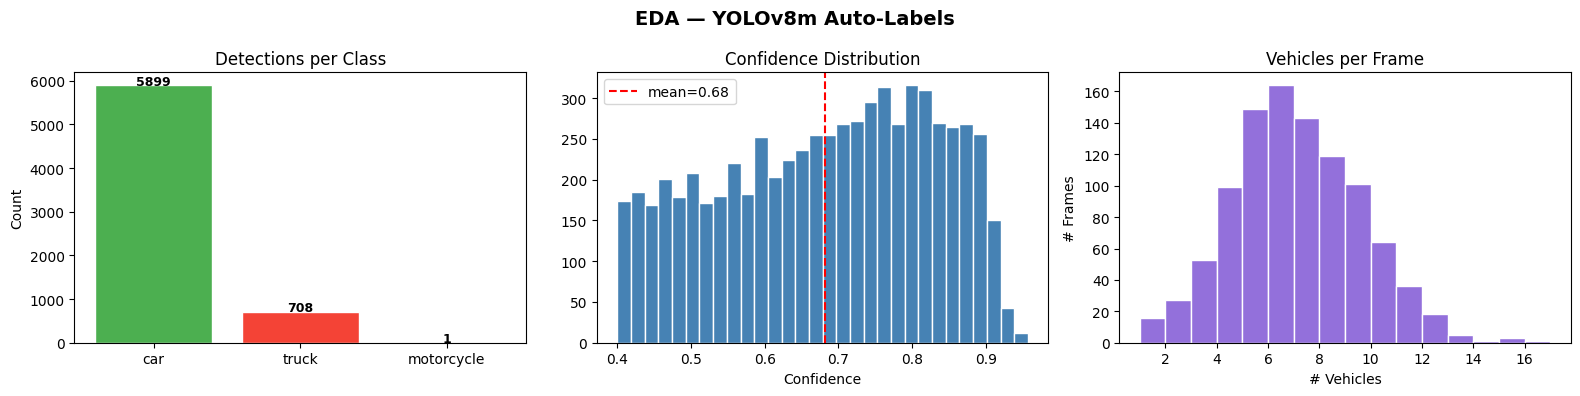

High-confidence (≥0.70) detections: 49.7%


In [12]:
from collections import Counter

all_classes = [a['class'] for d in label_data for a in d['annotations']]
counts      = Counter(all_classes)
confs       = [a['confidence'] for d in label_data for a in d['annotations']]
det_counts  = [len(d['annotations']) for d in label_data]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('EDA — YOLOv8m Auto-Labels', fontsize=14, fontweight='bold')

# Class distribution
keys   = list(counts.keys())
colors = [CLASS_COLORS.get(k, '#9E9E9E') for k in keys]
bars   = axes[0].bar(keys, [counts[k] for k in keys], color=colors, edgecolor='white')
for bar, k in zip(bars, keys):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10, str(counts[k]),
                 ha='center', fontweight='bold', fontsize=9)
axes[0].set_title('Detections per Class')
axes[0].set_ylabel('Count')

# Confidence distribution
axes[1].hist(confs, bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(np.mean(confs), color='red', ls='--', label=f'mean={np.mean(confs):.2f}')
axes[1].set_title('Confidence Distribution')
axes[1].set_xlabel('Confidence')
axes[1].legend()

# Vehicles per frame
axes[2].hist(det_counts, bins=range(1, max(det_counts)+2),
             color='mediumpurple', edgecolor='white')
axes[2].set_title('Vehicles per Frame')
axes[2].set_xlabel('# Vehicles')
axes[2].set_ylabel('# Frames')

plt.tight_layout()
plt.savefig('outputs/eda_labels.png', dpi=110, bbox_inches='tight')
plt.show()
print(f'High-confidence (≥0.70) detections: '
      f'{sum(1 for c in confs if c >= 0.70)/len(confs)*100:.1f}%')

In [13]:
random.shuffle(label_data)
n          = len(label_data)
train_size = int(0.8 * n)
val_size   = int(0.1 * n)

train_data = label_data[:train_size]
val_data   = label_data[train_size : train_size + val_size]
test_data  = label_data[train_size + val_size:]

for name, split in [('train', train_data), ('val', val_data), ('test', test_data)]:
    with open(f'{name}_data.json', 'w') as f:
        json.dump(split, f)

print(f'Split  →  train: {len(train_data)}  |  val: {len(val_data)}  |  test: {len(test_data)}')

Split  →  train: 799  |  val: 99  |  test: 101


In [14]:
class SpeedEstimator:
    LK_PARAMS = dict(
        winSize   = (21, 21),
        maxLevel  = 3,
        criteria  = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01)
    )
    FEAT_PARAMS = dict(
        maxCorners   = 20,
        qualityLevel = 0.3,
        minDistance  = 7,
        blockSize    = 7
    )

    def __init__(self, fps=25.0, frame_skip=3, px_per_meter=8.0, smooth_n=5):
        self.dt           = frame_skip / fps
        self.px_per_meter = px_per_meter
        self.smooth_n     = smooth_n

        self._prev_gray:  np.ndarray | None = None
        self._speed_hist: dict[int, deque]  = defaultdict(lambda: deque(maxlen=smooth_n))
        self._last_speed: dict[int, float]  = {}

    def update(self, frame_bgr: np.ndarray,
               detections: list[dict]) -> dict[int, float]:
        gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)

        if self._prev_gray is None:
            self._prev_gray = gray
            return {}

        speeds = {}
        for det in detections:
            tid  = det['track_id']
            x1   = max(0, int(det['x_min']))
            y1   = max(0, int(det['y_min']))
            x2   = min(gray.shape[1], int(det['x_max']))
            y2   = min(gray.shape[0], int(det['y_max']))

            roi_prev = self._prev_gray[y1:y2, x1:x2]
            roi_curr = gray[y1:y2, x1:x2]

            if roi_prev.size == 0 or roi_curr.size == 0:
                continue

            pts = cv2.goodFeaturesToTrack(roi_prev, **self.FEAT_PARAMS)
            if pts is None or len(pts) == 0:
                speeds[tid] = self._last_speed.get(tid, 0.0)
                continue

            pts_next, status, _ = cv2.calcOpticalFlowPyrLK(
                roi_prev, roi_curr, pts, None, **self.LK_PARAMS
            )

            good_prev = pts[status.ravel() == 1]
            good_next = pts_next[status.ravel() == 1]

            if len(good_prev) == 0:
                speeds[tid] = self._last_speed.get(tid, 0.0)
                continue

            displacements = np.linalg.norm(good_next - good_prev, axis=1)

            threshold     = np.percentile(displacements, 90)
            filtered      = displacements[displacements <= threshold]
            mean_px       = filtered.mean() if len(filtered) else displacements.mean()

            dist_m  = mean_px / self.px_per_meter
            speed_s = dist_m  / self.dt           # m/s
            speed_k = speed_s * 3.6               # km/h

            self._speed_hist[tid].append(speed_k)
            smoothed          = np.mean(self._speed_hist[tid])
            self._last_speed[tid] = smoothed
            speeds[tid]       = smoothed

        self._prev_gray = gray
        return speeds

    def get_speed(self, track_id: int) -> float:
        return self._last_speed.get(track_id, 0.0)


print('SpeedEstimator class defined')

SpeedEstimator class defined


In [15]:
import supervision as sv

cap    = cv2.VideoCapture(VIDEO_PATH)
FPS    = cap.get(cv2.CAP_PROP_FPS)
W      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

tracker = sv.ByteTrack()
speed_est = SpeedEstimator(
    fps          = FPS,
    frame_skip   = SKIP,
    px_per_meter = 8.0,
    smooth_n     = 5
)

OUT_VIDEO = 'outputs/tracked_with_speed.mp4'
fourcc    = cv2.VideoWriter_fourcc(*'mp4v')
writer    = cv2.VideoWriter(OUT_VIDEO, fourcc, FPS/SKIP, (W, H))

FONT       = cv2.FONT_HERSHEY_SIMPLEX
CLASS_BGR  = {
    'car':        (76, 175, 80),    # green
    'motorcycle': (33, 150, 243),   # blue
    'bus':        (255, 152, 0),    # orange
    'truck':      (244, 67, 54),    # red
}

track_records: dict[int, dict] = {}

frame_idx  = 0
saved_idx  = 0
PROCESS_MAX = 600

print('Processing video …')
t0 = time.time()

while saved_idx < PROCESS_MAX:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_idx % SKIP != 0:
        frame_idx += 1
        continue

    results = yolo.predict(frame, imgsz=640, conf=0.40, iou=0.45, verbose=False)[0]

    mask    = np.isin(results.boxes.cls.cpu().numpy().astype(int),
                      list(VEHICLE_CLASSES.keys()))
    boxes   = results.boxes.xyxy.cpu().numpy()[mask]
    confs_v = results.boxes.conf.cpu().numpy()[mask]
    cls_ids = results.boxes.cls.cpu().numpy()[mask].astype(int)

    if len(boxes) == 0:
        frame_idx += 1
        saved_idx += 1
        writer.write(frame)
        continue

    sv_dets = sv.Detections(
        xyxy       = boxes,
        confidence = confs_v,
        class_id   = cls_ids
    )
    tracked = tracker.update_with_detections(sv_dets)

    det_list = []
    for i in range(len(tracked)):
        tid = int(tracked.tracker_id[i])
        x1, y1, x2, y2 = tracked.xyxy[i]
        det_list.append({
            'track_id': tid,
            'x_min': x1, 'y_min': y1,
            'x_max': x2, 'y_max': y2
        })
    speeds_now = speed_est.update(frame, det_list)

    annotated = frame.copy()
    for i in range(len(tracked)):
        x1, y1, x2, y2 = [int(v) for v in tracked.xyxy[i]]
        tid      = int(tracked.tracker_id[i])
        cls_id   = int(tracked.class_id[i])
        cls_name = VEHICLE_CLASSES.get(cls_id, 'vehicle')
        conf_v   = float(tracked.confidence[i])
        speed_k  = speeds_now.get(tid, speed_est.get_speed(tid))
        bgr      = CLASS_BGR.get(cls_name, (200, 200, 200))

        # Box
        cv2.rectangle(annotated, (x1, y1), (x2, y2), bgr, 2)

        # Top label: class + ID
        label_top = f'{cls_name} #{tid}'
        (tw, th), _ = cv2.getTextSize(label_top, FONT, 0.55, 2)
        cv2.rectangle(annotated, (x1, y1 - th - 8), (x1 + tw + 4, y1), bgr, -1)
        cv2.putText(annotated, label_top, (x1 + 2, y1 - 4),
                    FONT, 0.55, (255, 255, 255), 2, cv2.LINE_AA)

        # Bottom label: speed
        label_bot = f'{speed_k:.0f} km/h'
        (bw, bh), _ = cv2.getTextSize(label_bot, FONT, 0.6, 2)
        cv2.rectangle(annotated, (x1, y2), (x1 + bw + 6, y2 + bh + 8), bgr, -1)
        cv2.putText(annotated, label_bot, (x1 + 3, y2 + bh + 2),
                    FONT, 0.6, (255, 255, 255), 2, cv2.LINE_AA)

        crop = frame[max(0,y1):y2, max(0,x1):x2]
        if tid not in track_records:
            track_records[tid] = {
                'class':  cls_name,
                'confs':  [],
                'speeds': [],
                'crop':   crop if crop.size > 0 else None
            }
        track_records[tid]['confs'].append(conf_v)
        track_records[tid]['speeds'].append(speed_k)
        if crop.size > 0 and track_records[tid]['crop'] is None:
            track_records[tid]['crop'] = crop

    # Frame counter overlay
    cv2.putText(annotated, f'Frame {saved_idx+1} | Vehicles: {len(tracked)}',
                (10, 30), FONT, 0.7, (255, 255, 255), 2, cv2.LINE_AA)

    writer.write(annotated)
    frame_idx += 1
    saved_idx += 1

cap.release()
writer.release()

elapsed = time.time() - t0
print(f'Pipeline done in {elapsed:.1f}s')
print(f'   Unique tracks : {len(track_records)}')
print(f'   Output video  : {OUT_VIDEO}')

Processing video …
Pipeline done in 26.4s
   Unique tracks : 175
   Output video  : outputs/tracked_with_speed.mp4


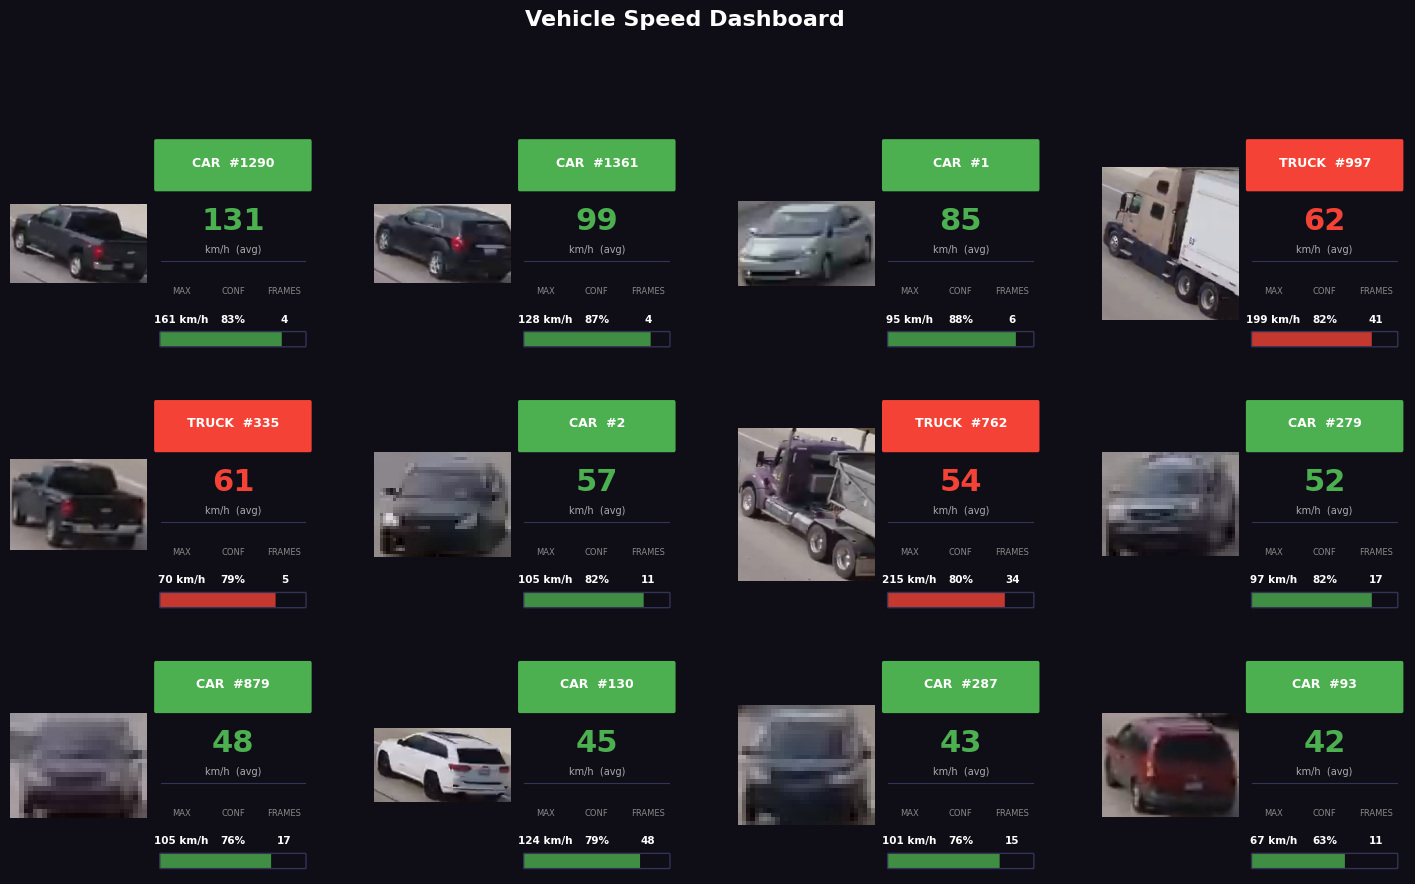

Dashboard saved  (12 cards)


In [16]:
def draw_car_card(ax_img, ax_info, record: dict, track_id: int):
    cls_name   = record['class']
    speeds     = [s for s in record['speeds'] if s > 0]
    confs      = record['confs']
    crop       = record['crop']
    color      = CLASS_COLORS.get(cls_name, '#9E9E9E')

    avg_speed  = np.mean(speeds)  if speeds else 0.0
    max_speed  = np.max(speeds)   if speeds else 0.0
    avg_conf   = np.mean(confs)   if confs  else 0.0

    ax_img.set_facecolor('#1a1a2e')
    if crop is not None and crop.size > 0:
        ax_img.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    else:
        ax_img.text(0.5, 0.5, ha='center', va='center',
                    fontsize=28, transform=ax_img.transAxes)
    ax_img.axis('off')

    for spine in ax_img.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
        spine.set_visible(True)

    ax_info.set_facecolor('#16213e')
    ax_info.axis('off')

    ax_info.add_patch(patches.FancyBboxPatch(
        (0.02, 0.75), 0.96, 0.22,
        boxstyle='round,pad=0.01', linewidth=0,
        facecolor=color, transform=ax_info.transAxes
    ))
    ax_info.text(0.50, 0.87,
                 f'{cls_name.upper()}  #{track_id}',
                 ha='center', va='center', fontsize=9,
                 fontweight='bold', color='white',
                 transform=ax_info.transAxes)

    ax_info.text(0.50, 0.60,
                 f'{avg_speed:.0f}',
                 ha='center', va='center', fontsize=22,
                 fontweight='bold', color=color,
                 transform=ax_info.transAxes)
    ax_info.text(0.50, 0.47,
                 'km/h  (avg)',
                 ha='center', va='center', fontsize=7,
                 color='#aaaaaa', transform=ax_info.transAxes)

    ax_info.axhline(0.42, color='#333355', linewidth=0.8,
                    xmin=0.05, xmax=0.95)

    stats = [
        ('MAX', f'{max_speed:.0f} km/h'),
        ('CONF', f'{avg_conf*100:.0f}%'),
        ('FRAMES', str(len(confs))),
    ]
    for col, (label, value) in enumerate(stats):
        xpos = 0.18 + col * 0.32
        ax_info.text(xpos, 0.28, label,
                     ha='center', va='center', fontsize=6,
                     color='#888888', transform=ax_info.transAxes)
        ax_info.text(xpos, 0.15, value,
                     ha='center', va='center', fontsize=7.5,
                     fontweight='bold', color='white',
                     transform=ax_info.transAxes)

    ax_info.add_patch(patches.FancyBboxPatch(
        (0.05, 0.03), 0.90 * avg_conf, 0.06,
        boxstyle='round,pad=0.005', linewidth=0,
        facecolor=color, alpha=0.8, transform=ax_info.transAxes
    ))
    ax_info.add_patch(patches.FancyBboxPatch(
        (0.05, 0.03), 0.90, 0.06,
        boxstyle='round,pad=0.005', linewidth=1,
        edgecolor='#333355', facecolor='none', transform=ax_info.transAxes
    ))

eligible = {
    tid: rec for tid, rec in track_records.items()
    if len(rec['speeds']) >= 3 and rec['crop'] is not None
}

sorted_tracks = sorted(
    eligible.items(),
    key=lambda x: np.mean([s for s in x[1]['speeds'] if s > 0]),
    reverse=True
)

SHOW   = min(12, len(sorted_tracks))
COLS   = 4
ROWS   = -(-SHOW // COLS)

fig = plt.figure(figsize=(COLS * 4.5, ROWS * 3.2), facecolor='#0f0e17')
fig.suptitle('Vehicle Speed Dashboard', fontsize=16,
             fontweight='bold', color='white', y=1.01)

for idx, (tid, rec) in enumerate(sorted_tracks[:SHOW]):
    row, col = divmod(idx, COLS)

    outer_ax = fig.add_subplot(ROWS, COLS, idx + 1)
    outer_ax.set_visible(False)

    pos = outer_ax.get_position()

    ax_img  = fig.add_axes([pos.x0,          pos.y0, pos.width * 0.45, pos.height])
    ax_info = fig.add_axes([pos.x0 + pos.width * 0.47, pos.y0,
                            pos.width * 0.53, pos.height])
    draw_car_card(ax_img, ax_info, rec, tid)

plt.savefig('outputs/car_speed_dashboard.png', dpi=130,
            bbox_inches='tight', facecolor='#0f0e17')
plt.show()
print(f'Dashboard saved  ({SHOW} cards)')

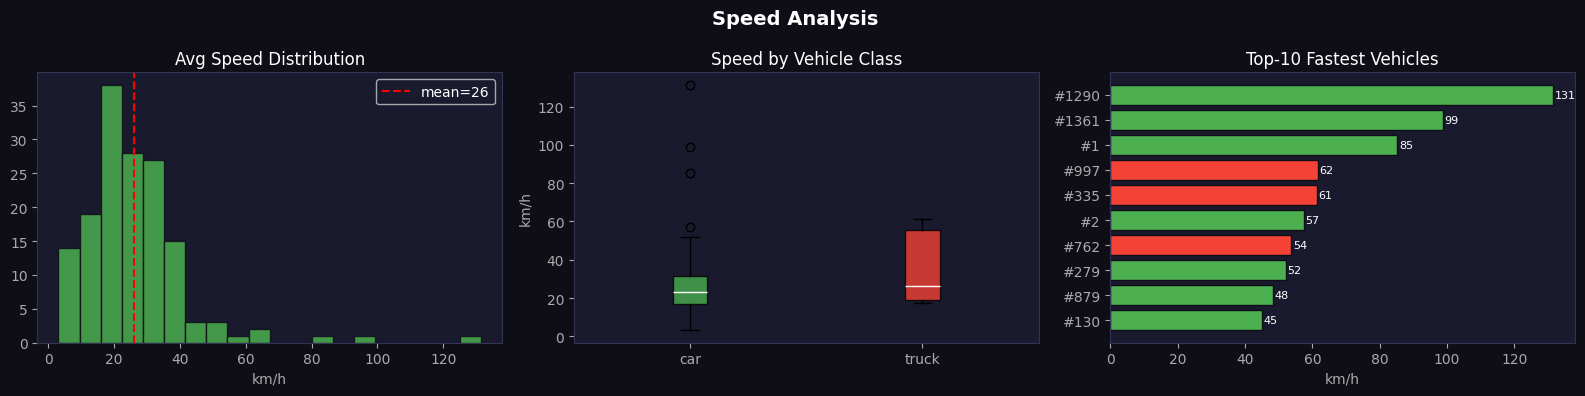

In [17]:
all_avg_speeds = {}
class_speeds   = defaultdict(list)

for tid, rec in eligible.items():
    valid = [s for s in rec['speeds'] if s > 0]
    if not valid:
        continue
    avg = np.mean(valid)
    all_avg_speeds[tid] = avg
    class_speeds[rec['class']].append(avg)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor='#0f0e17')
fig.suptitle('Speed Analysis', fontsize=14, fontweight='bold', color='white')

for ax in axes:
    ax.set_facecolor('#1a1a2e')
    ax.tick_params(colors='#aaaaaa')
    for s in ax.spines.values():
        s.set_edgecolor('#333355')

# Overall speed histogram
all_s = list(all_avg_speeds.values())
axes[0].hist(all_s, bins=20, color='#4CAF50', edgecolor='#0f0e17', alpha=0.85)
axes[0].axvline(np.mean(all_s), color='red', ls='--',
                label=f'mean={np.mean(all_s):.0f}')
axes[0].set_title('Avg Speed Distribution', color='white')
axes[0].set_xlabel('km/h', color='#aaaaaa')
axes[0].legend(facecolor='#1a1a2e', labelcolor='white')

# Per-class boxplot
cls_list   = [c for c in CLASS_COLORS if c in class_speeds]
data_boxes = [class_speeds[c] for c in cls_list]
bp = axes[1].boxplot(data_boxes, patch_artist=True, medianprops={'color':'white'})
for patch, cls in zip(bp['boxes'], cls_list):
    patch.set_facecolor(CLASS_COLORS[cls])
    patch.set_alpha(0.8)
axes[1].set_xticks(range(1, len(cls_list)+1))
axes[1].set_xticklabels(cls_list, color='#aaaaaa')
axes[1].set_title('Speed by Vehicle Class', color='white')
axes[1].set_ylabel('km/h', color='#aaaaaa')

# Top-10 fastest vehicles
top10 = sorted(all_avg_speeds.items(), key=lambda x: x[1], reverse=True)[:10]
tids  = [f'#{t}' for t, _ in top10]
spds  = [s for _, s in top10]
colors_bar = [CLASS_COLORS.get(eligible[t]['class'], '#9E9E9E') for t, _ in top10]
bars = axes[2].barh(tids, spds, color=colors_bar, edgecolor='#0f0e17')
for bar, s in zip(bars, spds):
    axes[2].text(s + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{s:.0f}', va='center', color='white', fontsize=8)
axes[2].set_title('Top-10 Fastest Vehicles', color='white')
axes[2].set_xlabel('km/h', color='#aaaaaa')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('outputs/speed_analysis.png', dpi=110,
            bbox_inches='tight', facecolor='#0f0e17')
plt.show()

In [18]:
test_dataset = pd.read_json('test_data.json')

def iou_single(b1, b2):
    ix = max(0, min(b1[2],b2[2]) - max(b1[0],b2[0]))
    iy = max(0, min(b1[3],b2[3]) - max(b1[1],b2[1]))
    inter = ix * iy
    a1    = (b1[2]-b1[0]) * (b1[3]-b1[1])
    a2    = (b2[2]-b2[0]) * (b2[3]-b2[1])
    union = a1 + a2 - inter
    return inter / union if union > 0 else 0.0

IOU_THRESH = 0.50
tp, fp, fn = 0, 0, 0
all_ious   = []

print(f'Evaluating on {len(test_dataset)} test frames …')

for _, row in test_dataset.iterrows():
    gt_boxes   = [[a['x_min'], a['y_min'], a['x_max'], a['y_max']]
                  for a in row['annotations']]
    img_path   = f'frames/{row["filename"]}'
    if not os.path.exists(img_path):
        continue

    result     = yolo.predict(img_path, imgsz=640, conf=0.35, verbose=False)[0]
    mask       = np.isin(result.boxes.cls.cpu().numpy().astype(int),
                         list(VEHICLE_CLASSES.keys()))
    pred_boxes = result.boxes.xyxy.cpu().numpy()[mask].tolist()

    matched = set()
    for gt in gt_boxes:
        best_iou, best_j = 0.0, -1
        for j, pd in enumerate(pred_boxes):
            if j in matched:
                continue
            iou = iou_single(gt, pd)
            if iou > best_iou:
                best_iou, best_j = iou, j
        all_ious.append(best_iou)
        if best_iou >= IOU_THRESH:
            tp += 1
            matched.add(best_j)
        else:
            fn += 1
    fp += len(pred_boxes) - len(matched)

precision = tp / (tp + max(fp, 1e-6))
recall    = tp / (tp + max(fn, 1e-6))
f1        = 2*precision*recall / (precision + recall + 1e-6)
mean_iou  = np.mean(all_ious)

print('  DETECTION EVALUATION — TEST SET')
print(f'  Mean IoU          : {mean_iou:.4f}  ({mean_iou*100:.1f}%)')
print(f'  Precision @IoU0.5 : {precision:.4f}  ({precision*100:.1f}%)')
print(f'  Recall    @IoU0.5 : {recall:.4f}  ({recall*100:.1f}%)')
print(f'  F1 Score          : {f1:.4f}')
print(f'  TP / FP / FN      : {tp} / {fp} / {fn}')

Evaluating on 101 test frames …
  DETECTION EVALUATION — TEST SET
  Mean IoU          : 0.9972  (99.7%)
  Precision @IoU0.5 : 0.9476  (94.8%)
  Recall    @IoU0.5 : 1.0000  (100.0%)
  F1 Score          : 0.9731
  TP / FP / FN      : 651 / 36 / 0


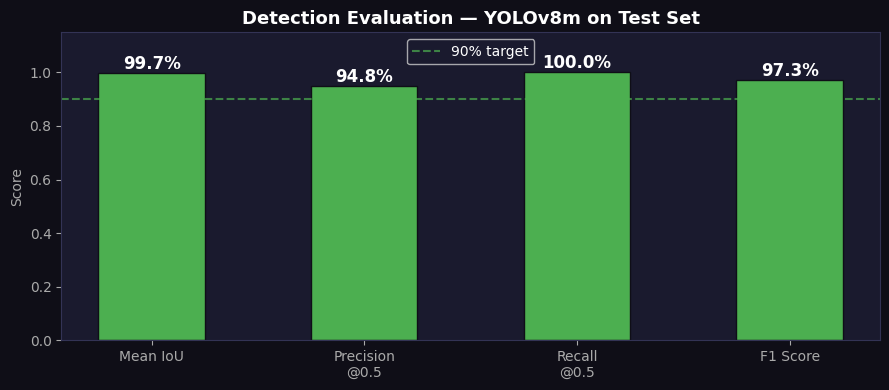

In [19]:
metric_names  = ['Mean IoU', 'Precision\n@0.5', 'Recall\n@0.5', 'F1 Score']
metric_values = [mean_iou, precision, recall, f1]

fig, ax = plt.subplots(figsize=(9, 4), facecolor='#0f0e17')
ax.set_facecolor('#1a1a2e')
for s in ax.spines.values():
    s.set_edgecolor('#333355')

bar_colors = ['#4CAF50' if v >= 0.90 else '#FF9800' if v >= 0.70 else '#F44336'
              for v in metric_values]
bars = ax.bar(metric_names, metric_values, color=bar_colors,
              edgecolor='#0f0e17', width=0.5)

for bar, val in zip(bars, metric_values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.015,
            f'{val*100:.1f}%', ha='center',
            fontweight='bold', fontsize=12, color='white')

ax.axhline(0.90, color='#4CAF50', ls='--', alpha=0.7, label='90% target')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
ax.set_title('Detection Evaluation — YOLOv8m on Test Set',
             fontsize=13, fontweight='bold', color='white')
ax.legend(facecolor='#1a1a2e', labelcolor='white')

plt.tight_layout()
plt.savefig('outputs/eval_metrics.png', dpi=110,
            bbox_inches='tight', facecolor='#0f0e17')
plt.show()

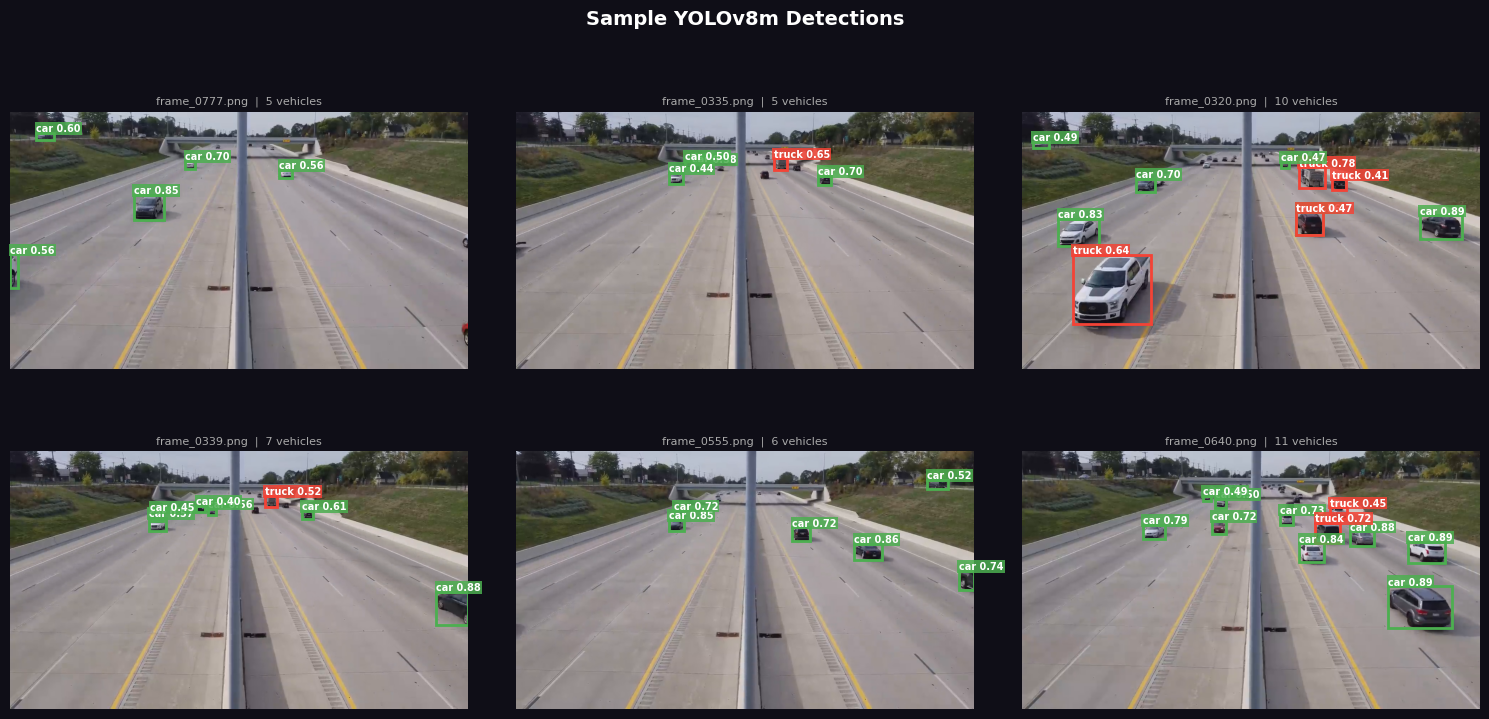

In [20]:
samples = random.sample(label_data, min(6, len(label_data)))
fig, axes = plt.subplots(2, 3, figsize=(15, 8), facecolor='#0f0e17')
fig.suptitle('Sample YOLOv8m Detections', fontsize=14,
             fontweight='bold', color='white')

for ax, item in zip(axes.flatten(), samples):
    img = cv2.cvtColor(cv2.imread(f'frames/{item["filename"]}'), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_facecolor('#1a1a2e')
    for ann in item['annotations']:
        x1, y1 = ann['x_min'], ann['y_min']
        bw     = ann['x_max'] - x1
        bh     = ann['y_max'] - y1
        color  = CLASS_COLORS.get(ann['class'], '#ffffff')
        ax.add_patch(patches.Rectangle((x1, y1), bw, bh,
                                        linewidth=2, edgecolor=color, facecolor='none'))
        ax.text(x1, y1 - 4,
                f"{ann['class']} {ann['confidence']:.2f}",
                color='white', fontsize=7, fontweight='bold',
                bbox=dict(facecolor=color, alpha=0.85, pad=1, edgecolor='none'))
    ax.set_title(f"{item['filename']}  |  {len(item['annotations'])} vehicles",
                 fontsize=8, color='#aaaaaa')
    ax.axis('off')

plt.tight_layout()
plt.savefig('outputs/sample_detections.png', dpi=110,
            bbox_inches='tight', facecolor='#0f0e17')
plt.show()